<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 828 | Val: 203 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[InceptionNet v3] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[InceptionNet v3] Epoch   1/100 | LR: 1.00e-04 | train loss 1.6247 acc 0.512 | val loss 0.9872 acc 0.463 *


[InceptionNet v3] Epoch   2/100 | LR: 1.00e-04 | train loss 1.1671 acc 0.571 | val loss 0.6703 acc 0.749 *


[InceptionNet v3] Epoch   3/100 | LR: 1.00e-04 | train loss 0.9138 acc 0.721 | val loss 0.6145 acc 0.759 *


[InceptionNet v3] Epoch   4/100 | LR: 1.00e-04 | train loss 0.5991 acc 0.802 | val loss 0.6033 acc 0.759 *


...

[InceptionNet v3] Epoch  15/100 | LR: 1.00e-05 | train loss 0.1927 acc 0.929 | val loss 0.5217 acc 0.818


[InceptionNet v3] Epoch  16/100 | LR: 1.00e-05 | train loss 0.0825 acc 0.986 | val loss 0.5274 acc 0.847


[InceptionNet v3] Epoch  17/100 | LR: 1.00e-05 | train loss 0.0929 acc 0.963 | val loss 0.5204 acc 0.837


[InceptionNet v3] Epoch  18/100 | LR: 1.00e-05 | train loss 0.0863 acc 0.973 | val loss 0.5286 acc 0.847


[InceptionNet v3] Epoch  19/100 | LR: 1.00e-05 | train loss 0.0795 acc 0.965 | val loss 0.5649 acc 0.842

[InceptionNet v3] No val loss improvement for 10 epochs — stopping early at epoch 19.

[InceptionNet v3] Restored best checkpoint (val loss = 0.4805)


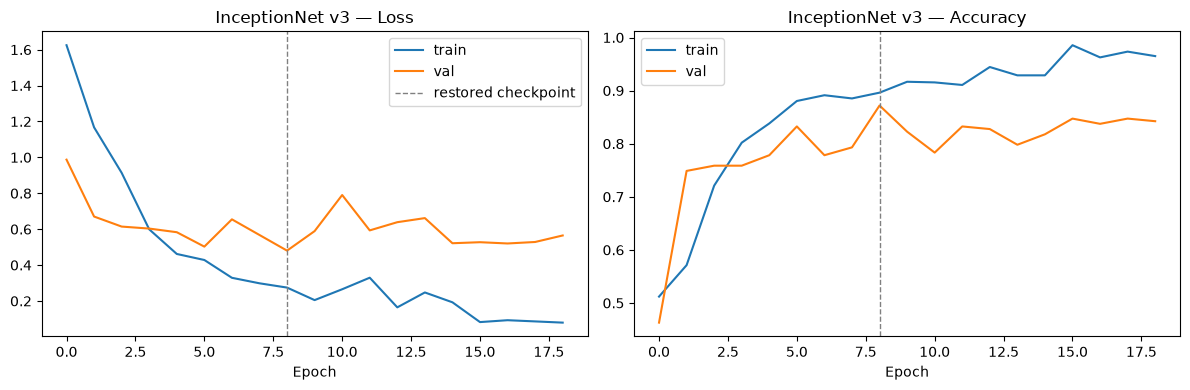

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

[InceptionNet v3] Test accuracy: 0.654


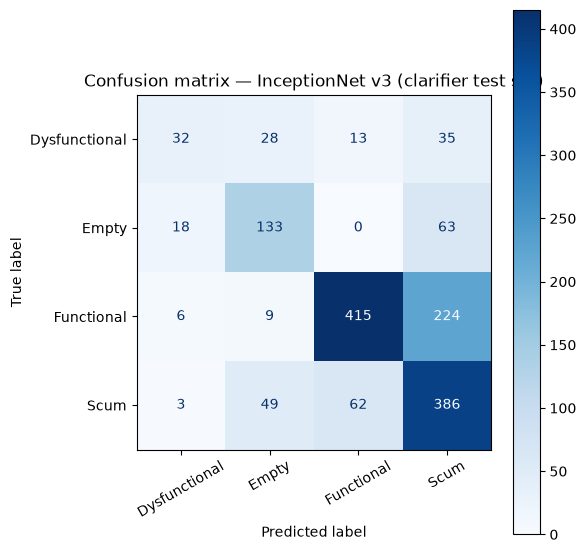

               precision    recall  f1-score   support

Dysfunctional      0.542     0.296     0.383       108
        Empty      0.607     0.621     0.614       214
   Functional      0.847     0.635     0.726       654
         Scum      0.545     0.772     0.639       500

     accuracy                          0.654      1476
    macro avg      0.635     0.581     0.591      1476
 weighted avg      0.688     0.654     0.655      1476



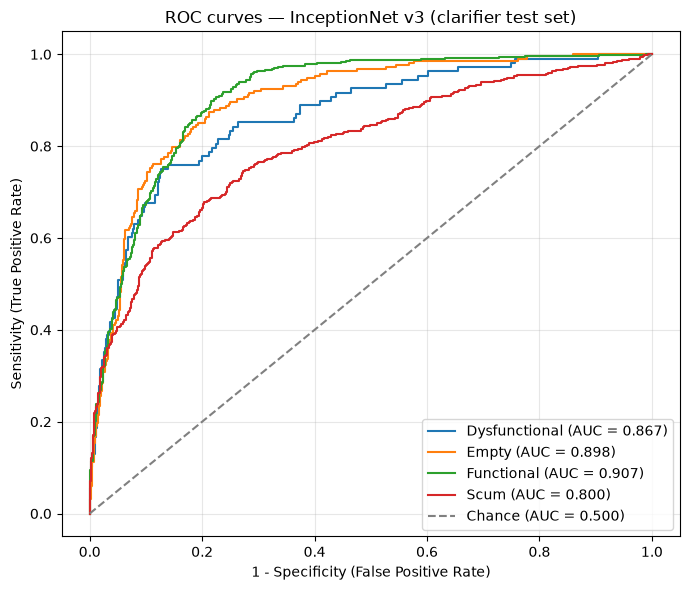

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.867
  Empty          : 0.898
  Functional     : 0.907
  Scum           : 0.800

Mean AUC (over 4/4 classes with test examples): 0.868


(np.float64(0.6544715447154471),
 {'Dysfunctional': 0.8667560103963614,
  'Empty': 0.8981515766399573,
  'Functional': 0.9073063386831551,
  'Scum': 0.8004918032786886})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/results_clarifier_inception_v3_CapeFlats.pkl
Saved model weights to ../models/clarifier_inception_v3_cnn.pt
